In [1]:
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from typing import TypedDict,Literal
from typing_extensions import Annotated

In [2]:
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph,START,END
import os
from langchain_core.messages import SystemMessage,HumanMessage,BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv


In [3]:
load_dotenv
project =os.getenv('GOOGLE_CLOUD_PROJECT')


In [4]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash-lite",
    vertexai=True,
    project=project
)

In [5]:
from langgraph.graph import MessagesState

In [6]:
def node_1(state:MessagesState):
    role =[SystemMessage(content="You are expert in the field of software")]
    response = llm.invoke(role + state["messages"])
    return{"messages": response}

In [7]:
def node_2(state: MessagesState):
    role = [SystemMessage(content="You are helpful assistant")]
    response=llm.invoke(role+state["messages"])
    return{"messages": response}


In [8]:
graph = StateGraph(MessagesState)

In [9]:
graph.add_node("expert",node_1)
graph.add_node("assistant",node_2)

In [10]:
graph.set_entry_point("expert")
graph.add_edge("expert","assistant")
graph.set_finish_point("assistant")

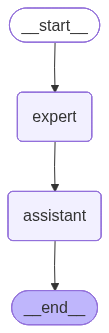

In [11]:
state_graph = graph.compile()
state_graph

In [12]:
response = state_graph.invoke(
    {"messages":[HumanMessage(content="What is class ?")]})

In [13]:
for message in response['messages']:
    print(message.content)

What is class ?
In the realm of software development, particularly in **Object-Oriented Programming (OOP)**, a **class** is a fundamental concept. It serves as a **blueprint** or a **template** for creating objects. Think of it as a design document that defines the structure and behavior of a particular type of entity.

Here's a breakdown of what a class is and its key components:

**1. Blueprint/Template:**

*   Just like a blueprint for a house defines its rooms, dimensions, and layout, a class defines the characteristics and actions that objects of that class will possess.
*   It doesn't *do* anything on its own; it's a description.

**2. Objects (Instances):**

*   When you create an actual entity based on a class blueprint, you're creating an **object** or an **instance** of that class.
*   You can create multiple objects from the same class, each with its own unique state (values for its attributes).

**3. Key Components of a Class:**

*   **Attributes (or Properties, Fields, Dat

In [14]:
graph = StateGraph(MessagesState)

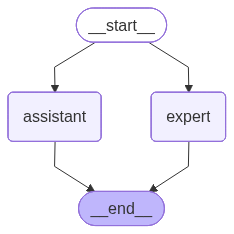

In [15]:
graph.add_node("expert",node_1)
graph.add_node("assistant",node_2)
graph.set_entry_point("expert")
graph.set_entry_point("assistant")
graph.set_finish_point("assistant")
graph.set_finish_point("expert")
state_graph = graph.compile()
state_graph

In [16]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

for message in response['messages']:
    print(message.content)

What is class ?
In programming, a **class** is a fundamental concept in **object-oriented programming (OOP)**. It acts as a **blueprint** or a **template** for creating objects. Think of it like a cookie cutter: the cookie cutter itself is the class, and the cookies you make with it are the objects.

Here's a breakdown of what a class is and what it contains:

**Key Concepts:**

*   **Blueprint/Template:** A class defines the common properties and behaviors that a group of objects will share. It specifies what data an object of that class will hold and what actions it can perform.
*   **Objects:** Objects are instances of a class. When you create an object from a class, you are creating a concrete realization of that blueprint. Each object has its own unique set of data (its state) but shares the same structure and behaviors defined by the class.
*   **Encapsulation:** Classes bundle data (attributes) and methods (behaviors) together. This means that the data is directly accessible and

In [17]:
class ExtendedMessagesState(MessagesState):
    expert_one: str = "Software"
    expert_two: str = "Design"

In [18]:

def ask_question(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": response}
chat_graph = StateGraph(MessagesState)
chat_graph.add_node("chat", ask_question)
chat_graph.set_entry_point("chat")
chat_graph.set_finish_point("chat")
chat_state_graph = chat_graph.compile()

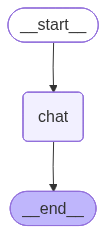

In [19]:
chat_state_graph

In [20]:
response = chat_state_graph.invoke({
    "messages": [HumanMessage("What is captial of france?")]
})

len(response['messages'])


2

In [21]:
response['messages'][-1].pretty_print

<bound method BaseMessage.pretty_print of AIMessage(content='The capital of France is **Paris**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019da064-c18c-71f1-88ca-ee64c968df48-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 8, 'total_tokens': 15, 'input_token_details': {'cache_read': 0}})>

In [22]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What are good spots in the city")]}
)
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

I'd love to help you find some good spots in the city! To give you the best recommendations, I need a little more information. **Could you tell me which city you're interested in?**

Once I know the city, I can help you find great places for:

*   **Food & Drink:** Restaurants, cafes, bars, breweries, unique eateries.
*   **Attractions & Landmarks:** Museums, historical sites, iconic buildings, viewpoints.
*   **Parks & Outdoors:** Green spaces, hiking trails, waterfronts, gardens.
*   **Entertainment & Culture:** Theaters, live music venues, art galleries, shopping districts.
*   **Family-Friendly Activities:** Zoos, aquariums, playgrounds, kid-friendly museums.
*   **Nightlife:** Clubs, lounges, rooftop bars.
*   **Hidden Gems:** Off-the-beaten-path places that locals love.

**In the meantime, here are some general categories of "good spots" that most cities have to offer:**

*   **The Central Park/Main

In [23]:
def response_from_llm(state: MessagesState):
    return {
        "messages": llm.invoke(state["messages"])
    }

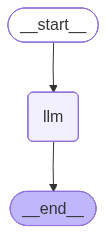

In [24]:
state_learning_graph = StateGraph(MessagesState)
state_learning_graph.add_node("llm", response_from_llm)

state_learning_graph.set_entry_point("llm")
state_learning_graph.set_finish_point("llm")

compiled_state_learning_graph = state_learning_graph.compile()
compiled_state_learning_graph

In [25]:
config = {"configurable": {"thread_id": "1"}}

input_message = HumanMessage(content="Hi this is Ram speaking")
output = compiled_state_learning_graph.invoke(
    {
        "messages": [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

================================== Ai Message ==================================

Hi Ram! How can I help you today?


In [26]:
previous_message = output['messages']
previous_message

[HumanMessage(content='Hi this is Ram speaking', additional_kwargs={}, response_metadata={}, id='d72b5acb-4a74-4652-a5a7-364acd22b88c'),
 AIMessage(content='Hi Ram! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019da064-cec4-70a3-8828-da57e111b8d7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 10, 'total_tokens': 15, 'input_token_details': {'cache_read': 0}})]

In [27]:
input_message = HumanMessage(content="What is my name ?")
output = compiled_state_learning_graph.invoke(

        {"messages": previous_message + [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

================================== Ai Message ==================================

You just told me your name is Ram.


In [28]:
from langgraph.checkpoint.memory import InMemorySaver
memory_enabled_graph = state_learning_graph.compile(
    checkpointer= InMemorySaver()
)

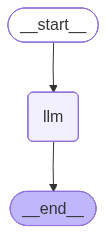

In [29]:
memory_enabled_graph

In [30]:
user1_config ={"configurable":{"thread_id":"1"}}
user2_config ={"configurable":{"thread_id":"2"}}

In [31]:
response = memory_enabled_graph.invoke(
    {
    "messages":[HumanMessage(content="Hi this is Ram")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

================================== Ai Message ==================================

Hi Ram! It's nice to meet you. How can I help you today?
length = 2


In [32]:
response = memory_enabled_graph.invoke(
    {
    "messages":[HumanMessage(content="I am from Hyderabad")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length = {len(response['messages'])}")

================================== Ai Message ==================================

That's wonderful, Ram! Hyderabad is a fascinating city with so much history and culture. I've heard it's famous for its delicious biryani and its beautiful Charminar.

What brings you here today? Are you looking for information, want to chat about something, or need help with a task?
length = 4


In [33]:
response=memory_enabled_graph.invoke(
    {
        "messages":[HumanMessage(content="i live in Ameerpet")]
    },
    user1_config

)
response['messages'][-1].pretty_print()
print(f"length ={len(response['messages'])}")

================================== Ai Message ==================================

Ameerpet! That's a very well-known area in Hyderabad, especially for its IT training institutes. It's a bustling hub.

So, Ram from Ameerpet, Hyderabad, what can I do for you? Are you looking for something specific related to Ameerpet, or just making conversation?
length =6


In [55]:
response = memory_enabled_graph.invoke(
    {
        "messages":[HumanMessage(content="I live in Mumbai")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
print(f"length ={len(response['messages'])}")

================================== Ai Message ==================================

Okay, Ram. I understand that you live in Mumbai. That's a fantastic city!

Since I'm an AI, I don't have access to your personal information, so I don't know your specific address or even which neighborhood you reside in. My purpose is to provide information and complete tasks based on what you tell me, not to know your private details.

Is there anything specific you'd like to talk about regarding Mumbai, or is there something I can help you with? Perhaps you want to know about different areas, local attractions, or something else entirely?
length =16


In [54]:
response = memory_enabled_graph.invoke(
    {
        "messages":[HumanMessage(content="where i do live in Mumbai")]
    },
    user1_config
)
response['messages'][-1].pretty_print()
my_state = MessagesState(
    messages = response['messages']
    
)
print(f"length ={len(response['messages'])}")

================================== Ai Message ==================================

Ram, I understand you're asking where you live in Mumbai. However, as an AI, I **cannot** know your personal location. I don't have access to your real-world identity or whereabouts.

It's like asking me what you had for breakfast – I have no way of knowing that information unless you tell me.

To know where you live in Mumbai, you would need to tell me the name of the locality, neighborhood, or area.

Is there something specific you're trying to find out about a location in Mumbai, or are you curious about how I work?
length =14


In [53]:
response = memory_enabled_graph.invoke(
    {
        "messages":[HumanMessage(content="what is my name ")]
    },
    user2_config
)
response['messages'][-1].pretty_print()
print(f"length ={len(response['messages'])}")


================================== Ai Message ==================================

I do not know your name. I am a large language model, trained by Google.
length =4


In [51]:
def summarize(State:MessagesState):
    messages=State["messages"]
    response= llm.invoke([
        SystemMessage(content="Summarize the coversation"),
        *messages
    ]),
    user1_config
    return response
    




In [50]:
messages = summarize(my_state)
len(messages)


1

In [39]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

I do not know your name. I am a large language model, trained by Google.


In [40]:
from langgraph.runtime import Runtime
from langgraph.store.memory import InMemoryStore
class studentstate(MessagesState):
     name: str
     id: str
     dept: str

def process_student_info(state:studentstate,runtime: Runtime):
     content= f"Student {state['name']} from{state['dept']} has email {state['email']}"
     if True:
          preference = runtime.store.get(
               namespace=("students",state['name'],"preference"),
               key="preference",
          )
          if preference:
               content += f"and prefers {preference}"
     return{
          "messages": llm.invoke(
               [
                    SystemMessage(content="you are helful student advisor, Act as an employee of Delhi University"),
                    HumanMessage(
                         content=f"student {state['name']} from {state['dept']} has email {state['email']}"
                        *state['messages']
                         
                    )
               ]
          )
     }
          
def evaluate_result(state: studentstate,runtime: Runtime):
    if True:
         runtime.store.put(
              namespace=("students",state['name'],"preference"),
              key="preference",
              value=response['messages'][-1].content
         )
    return state
    
          
    


In [41]:
student_graph_builder = StateGraph(studentstate)
student_graph_builder.add_node("process", process_student_info)
student_graph_builder.add_node("evaluate",evaluate_result)

student_graph_builder.set_entry_point("process")
student_graph_builder.add_edge("process","evaluate")
student_graph_builder.set_finish_point("evaluate")


In [42]:
student_graph = student_graph_builder.compile(
    checkpointer=InMemorySaver(),
    store=InMemorySaver()
)

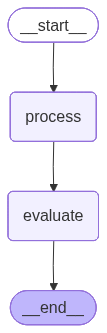

In [43]:
student_graph

In [44]:
student1_config = {"configurable": {"thread_id": "1"}}
student2_config = {"configurable": {"thread_id": "2"}}


response = student_graph.invoke(
    {
        "name": "Ram",
        "email": "ram@gmail.com",
        "dept": "commerce",
        "messages": [
            HumanMessage(content="I want to know Sports Activities, As i like football")]
    },
    config=student1_config
)

KeyError: 'email'

In [ ]:
def print_all_messages(messages: list[BaseMessage]):
    for message in messages:
        message.pretty_print()

In [ ]:
print_all_messages(response['messages'])

================================ Human Message =================================

I want to know Sports Activities, As i like football
================================== Ai Message ==================================

Hello Ram,

Greetings from Delhi University!

It's great to hear from you and that you're interested in exploring the sports activities available at the University, especially football. Delhi University has a very vibrant sports culture, and we encourage students to participate actively.

For football enthusiasts like yourself, here's what you need to know:

**1. Inter-College Football Competitions:**
*   Delhi University organizes annual inter-college football tournaments for both men and women. These are highly competitive and a fantastic platform to showcase your talent.
*   Most colleges have their own football teams that participate in these events.

**2. College Football Teams:**
*   **Join your College Team:** The first step is to connect with the Sports Officer or 

In [ ]:
response = student_graph.invoke(
    {
        "name": "Ram",
        "email": "ram@gmail.com",
        "dept": "commerce",
        "messages": [
            HumanMessage(
                content="What do i like ?"
            )
        ]
    },
    config=student1_config
)
print_all_messages(response['messages'])

================================ Human Message =================================

I want to know Sports Activities, As i like football
================================== Ai Message ==================================

Hello Ram,

Greetings from Delhi University!

It's great to hear from you and that you're interested in exploring the sports activities available at the University, especially football. Delhi University has a very vibrant sports culture, and we encourage students to participate actively.

For football enthusiasts like yourself, here's what you need to know:

**1. Inter-College Football Competitions:**
*   Delhi University organizes annual inter-college football tournaments for both men and women. These are highly competitive and a fantastic platform to showcase your talent.
*   Most colleges have their own football teams that participate in these events.

**2. College Football Teams:**
*   **Join your College Team:** The first step is to connect with the Sports Officer or 